# Explora aquí

Se recomienda utilizar este cuaderno con fines de exploración.

In [ ]:
import pandas as pd
import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_most-streamed_songs_on_Spotify"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML. like Gecko) Chrome/119.0.0.0 Safari/537.36"
}
response = requests.get(url, headers=headers)

tablas = pd.read_html(StringIO(response.text))
df = tablas[0]
print(df.head())
print(df.columns)



  Rank               Song                 Artist(s) Streams (billions)  \
0    1  "Blinding Lights"                The Weeknd              5.358   
1    2     "Shape of You"                Ed Sheeran              4.852   
2    3  "Sweater Weather"         The Neighbourhood              4.511   
3    4          "Starboy"  The Weeknd and Daft Punk              4.465   
4    5        "As It Was"              Harry Styles              4.342   

        Release date Ref.  
0   29 November 2019  [1]  
1     6 January 2017  [2]  
2    3 December 2012  [3]  
3  21 September 2016  [4]  
4       1 April 2022  [5]  
Index(['Rank', 'Song', 'Artist(s)', 'Streams (billions)', 'Release date',
       'Ref.'],
      dtype='str')


In [24]:
print(df.columns.tolist())


['Rank', 'Song', 'Artist(s)', 'Streams (billions)', 'Release date', 'Ref.']


In [25]:
df_limpio = df[['Song', 'Artist(s)', 'Streams (billions)', 'Release date']]
df_limpio = df_limpio.dropna()
print("¡Tabla limpia y lista!")
print(df_limpio.head())

¡Tabla limpia y lista!
                Song                 Artist(s) Streams (billions)  \
0  "Blinding Lights"                The Weeknd              5.358   
1     "Shape of You"                Ed Sheeran              4.852   
2  "Sweater Weather"         The Neighbourhood              4.511   
3          "Starboy"  The Weeknd and Daft Punk              4.465   
4        "As It Was"              Harry Styles              4.342   

        Release date  
0   29 November 2019  
1     6 January 2017  
2    3 December 2012  
3  21 September 2016  
4       1 April 2022  


In [26]:
import sqlite3
conexion = sqlite3.connect('spotify.db')
df_limpio.to_sql('canciones', conexion, index=False, if_exists='replace')
conexion.close()
print("¡Base de datos creada con éxito! 🎉")



¡Base de datos creada con éxito! 🎉


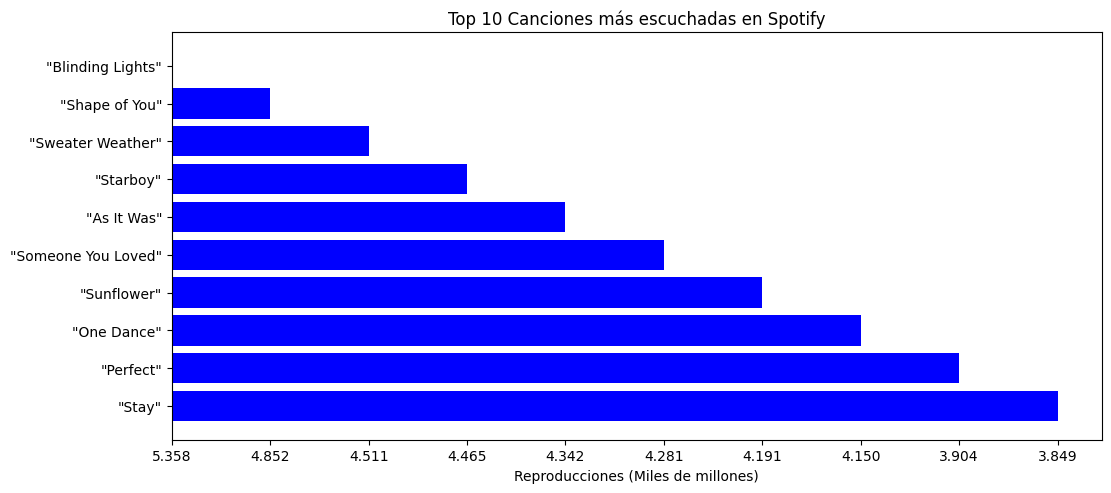

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1) 
top_10 = df_limpio.head(10)
plt.barh(top_10['Song'], top_10['Streams (billions)'], color='blue')
plt.xlabel('Reproducciones (Miles de millones)')
plt.title('Top 10 Canciones más escuchadas en Spotify')
plt.gca().invert_yaxis()

Text(0.5, 1.0, '¿De qué años son los grandes éxitos?')

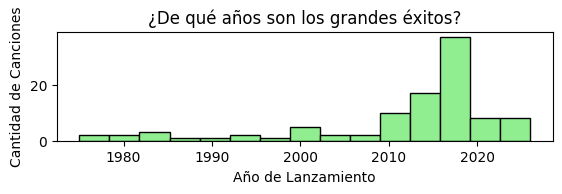

In [ ]:
plt.subplot(3, 1, 2)
df_limpio['Year'] = df_limpio['Release date'].str.extract(r'(\d{4})').astype(float)
plt.hist(df_limpio['Year'].dropna(), bins=15, color='lightgreen', edgecolor='black')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Cantidad de Canciones')
plt.title('¿De qué años son los grandes éxitos?')

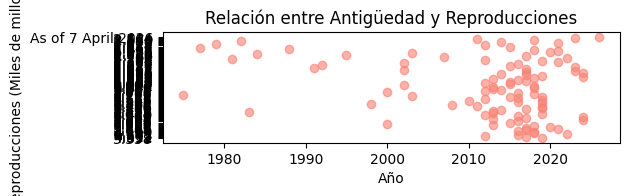

In [33]:
plt.subplot(3, 1, 3)
plt.scatter(df_limpio['Year'], df_limpio['Streams (billions)'], color='salmon', alpha=0.6)
plt.xlabel('Año')
plt.ylabel('Reproducciones (Miles de millones)')
plt.title('Relación entre Antigüedad y Reproducciones')

plt.tight_layout() 
plt.show()
